<a href="https://colab.research.google.com/github/gabis0604/projetos-da-faculdade-linguagem-de-sistemas/blob/main/unid3_aula_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##AULA 3 UNIDADE 3


In [24]:
import pandas as pd

url = (
    "https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/"
    "CotacaoDolarPeriodo(dataInicial=@dataInicial,dataFinalCotacao=@dataFinalCotacao)"
    "?@dataInicial='09-01-2026'"
    "&@dataFinalCotacao='09-21-2026'"
    "&$format=json"
)


df = pd.read_json(url)

df.head()

,@odata.context,value
0,https://was-p.bcnet.bcb.gov.br/olinda/servico/...,"{'cotacaoCompra': 5.1564, 'cotacaoVenda': 5.15..."
1,https://was-p.bcnet.bcb.gov.br/olinda/servico/...,"{'cotacaoCompra': 5.1267, 'cotacaoVenda': 5.12..."
2,https://was-p.bcnet.bcb.gov.br/olinda/servico/...,"{'cotacaoCompra': 5.0956, 'cotacaoVenda': 5.09..."
3,https://was-p.bcnet.bcb.gov.br/olinda/servico/...,"{'cotacaoCompra': 5.1247, 'cotacaoVenda': 5.12..."
4,https://was-p.bcnet.bcb.gov.br/olinda/servico/...,"{'cotacaoCompra': 5.085, 'cotacaoVenda': 5.085..."


In [25]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   @odata.context  14 non-null     object
 1   value           14 non-null     object
dtypes: object(2)
memory usage: 356.0+ bytes
None


In [26]:
print(df.head())

                                      @odata.context  \
0  https://was-p.bcnet.bcb.gov.br/olinda/servico/...   
1  https://was-p.bcnet.bcb.gov.br/olinda/servico/...   
2  https://was-p.bcnet.bcb.gov.br/olinda/servico/...   
3  https://was-p.bcnet.bcb.gov.br/olinda/servico/...   
4  https://was-p.bcnet.bcb.gov.br/olinda/servico/...   

                                               value  
0  {'cotacaoCompra': 5.1564, 'cotacaoVenda': 5.15...  
1  {'cotacaoCompra': 5.1267, 'cotacaoVenda': 5.12...  
2  {'cotacaoCompra': 5.0956, 'cotacaoVenda': 5.09...  
3  {'cotacaoCompra': 5.1247, 'cotacaoVenda': 5.12...  
4  {'cotacaoCompra': 5.085, 'cotacaoVenda': 5.085...  


In [27]:
df = pd.json_normalize(df['value'])
df.head()

,cotacaoCompra,cotacaoVenda,dataHoraCotacao
0,5.1564,5.1570,2026-09-01 13:06:03.857125
1,5.1267,5.1273,2026-09-02 13:02:37.601302
2,5.0956,5.0962,2026-09-03 13:06:38.232974
3,5.1247,5.1253,2026-09-04 13:03:59.556874
4,5.0850,5.0856,2026-09-08 13:02:38.447299


In [28]:
df.columns = ['compra', 'venda', 'data']

In [29]:
df.head()

,compra,venda,data
0,5.1564,5.1570,2026-09-01 13:06:03.857125
1,5.1267,5.1273,2026-09-02 13:02:37.601302
2,5.0956,5.0962,2026-09-03 13:06:38.232974
3,5.1247,5.1253,2026-09-04 13:03:59.556874
4,5.0850,5.0856,2026-09-08 13:02:38.447299


In [35]:
df['spread'] = df['venda'] - df['compra']
df.head()

,compra,venda,data,spread
0,5.1564,5.1570,2026-09-01 13:06:03.857125,0.0006
1,5.1267,5.1273,2026-09-02 13:02:37.601302,0.0006
2,5.0956,5.0962,2026-09-03 13:06:38.232974,0.0006
3,5.1247,5.1253,2026-09-04 13:03:59.556874,0.0006
4,5.0850,5.0856,2026-09-08 13:02:38.447299,0.0006


In [36]:
print(df.loc[0])

compra                        5.1564
venda                          5.157
data      2026-09-01 13:06:03.857125
spread                        0.0006
Name: 0, dtype: object


In [34]:
print(df.loc[0, 'data'])

2026-09-01 13:06:03.857125


In [37]:
caro = df[df['venda'] > 5]
print(f"Dias com dólar acima de R$5,00: {len(caro)}")
print(caro)

Dias com dólar acima de R$5,00: 14
    compra   venda                        data  spread
0   5.1564  5.1570  2026-09-01 13:06:03.857125  0.0006
1   5.1267  5.1273  2026-09-02 13:02:37.601302  0.0006
2   5.0956  5.0962  2026-09-03 13:06:38.232974  0.0006
3   5.1247  5.1253  2026-09-04 13:03:59.556874  0.0006
4   5.0850  5.0856  2026-09-08 13:02:38.447299  0.0006
5   5.0973  5.0979  2026-09-09 13:11:35.346979  0.0006
6   5.1143  5.1149   2026-09-10 13:09:28.70012  0.0006
7   5.0912  5.0918  2026-09-11 13:07:22.532196  0.0006
8   5.1690  5.1696  2026-09-14 13:10:08.144425  0.0006
9   5.1484  5.1490  2026-09-15 13:09:19.199664  0.0006
10  5.1520  5.1527   2026-09-16 13:05:30.35873  0.0007
11  5.1515  5.1521  2026-09-17 13:03:21.858212  0.0006
12  5.1569  5.1575  2026-09-18 13:03:34.742036  0.0006
13  5.1111  5.1117  2026-09-21 13:06:51.445645  0.0006


In [38]:
spread_alto = df[df['spread'] > 0.0001]
print(spread_alto[['data', 'compra', 'venda', 'spread']])

                          data  compra   venda  spread
0   2026-09-01 13:06:03.857125  5.1564  5.1570  0.0006
1   2026-09-02 13:02:37.601302  5.1267  5.1273  0.0006
2   2026-09-03 13:06:38.232974  5.0956  5.0962  0.0006
3   2026-09-04 13:03:59.556874  5.1247  5.1253  0.0006
4   2026-09-08 13:02:38.447299  5.0850  5.0856  0.0006
5   2026-09-09 13:11:35.346979  5.0973  5.0979  0.0006
6    2026-09-10 13:09:28.70012  5.1143  5.1149  0.0006
7   2026-09-11 13:07:22.532196  5.0912  5.0918  0.0006
8   2026-09-14 13:10:08.144425  5.1690  5.1696  0.0006
9   2026-09-15 13:09:19.199664  5.1484  5.1490  0.0006
10   2026-09-16 13:05:30.35873  5.1520  5.1527  0.0007
11  2026-09-17 13:03:21.858212  5.1515  5.1521  0.0006
12  2026-09-18 13:03:34.742036  5.1569  5.1575  0.0006
13  2026-09-21 13:06:51.445645  5.1111  5.1117  0.0006


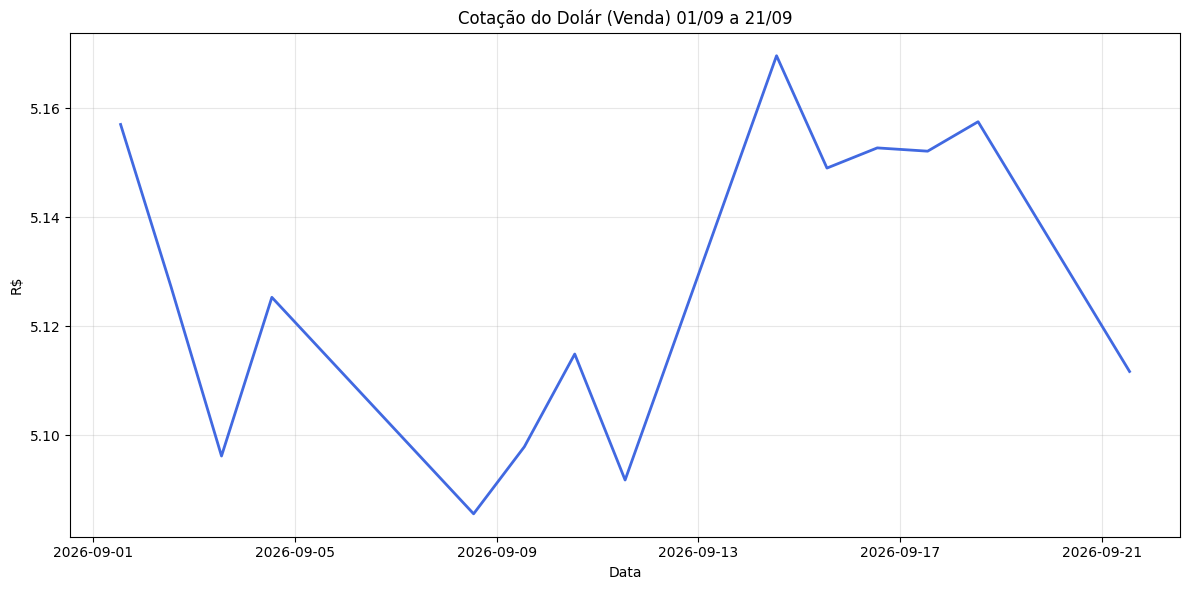

In [39]:
import matplotlib.pyplot as plt

df['data'] = pd.to_datetime(df['data'])

plt.figure(figsize=(12, 6))
plt.plot(df['data'], df['venda'], color='royalblue', linewidth=2)

plt.title('Cotação do Dolár (Venda) 01/09 a 21/09')
plt.xlabel('Data')
plt.ylabel('R$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
